In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.7 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 

In [2]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import cv2
import random
import shutil
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


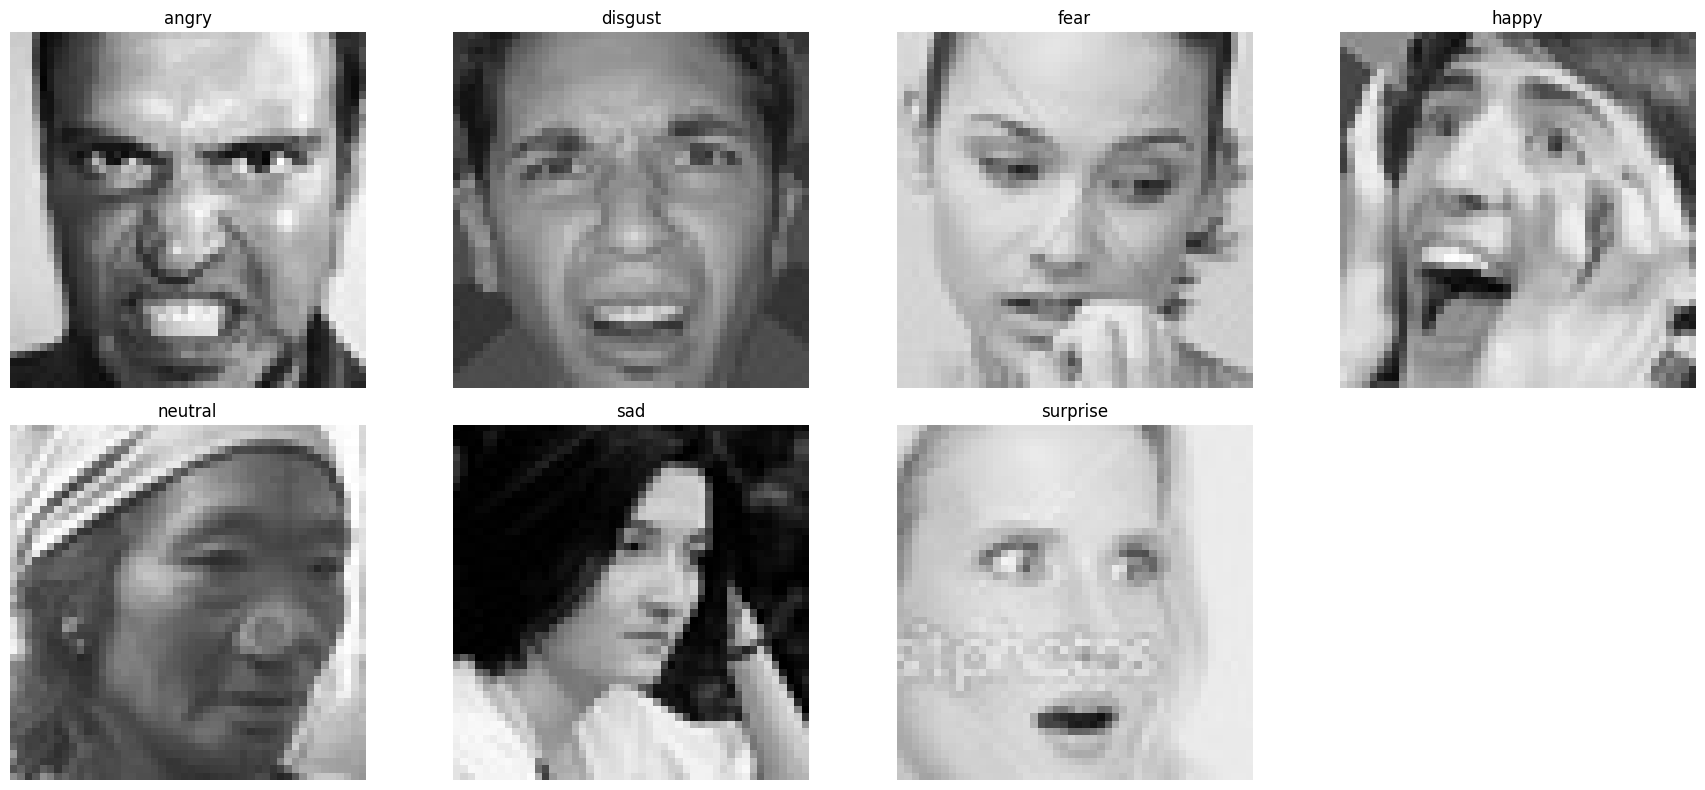

In [3]:
FER_Path='/kaggle/input/datasets/msambare/fer2013/train'
classes=['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
plt.figure(figsize=(18, 8))

for i, cls_name in enumerate(classes):
    class_dir = os.path.join(FER_Path, cls_name)
    image_files = os.listdir(class_dir)
    img_file = random.choice(image_files)  # Random image from class

    img_path = os.path.join(class_dir, img_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(cls_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
!pip install pathlib
!pip install scikit-learn

In [5]:
from sklearn.model_selection import StratifiedKFold
from pathlib import Path

Input='/kaggle/input/datasets/msambare/fer2013'
Output='/kaggle/working/Emotions_Yolo'
KFold_Dir='/kaggle/working/KFOLD'

classes=['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# ── Step 1: Collect ALL images + their class label ───────────────────────────
# We pool train and val together so K-Fold can re-split them properly
image_paths = []
label_ids   = []

for class_id, class_name in enumerate(classes):
    folder = Path(Input) / "train" / class_name
    imgs   = list(folder.glob("*.jpg")) + list(folder.glob("*.png"))
    print(f"  train/{class_name}: {len(imgs)} images")
    for img in imgs:
        image_paths.append(img)
        label_ids.append(class_id)

print(f"\nTotal: {len(image_paths)} images")

  train/angry: 3995 images
  train/disgust: 436 images
  train/fear: 4097 images
  train/happy: 7215 images
  train/neutral: 4965 images
  train/sad: 4830 images
  train/surprise: 3171 images

Total: 28709 images


In [6]:
# ── Step 2: K-Fold split with Data Balancing (Only Disgust) ───────────────────
N_FOLDS = 5
kf      = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
splits  = list(kf.split(image_paths, label_ids))

for fold_idx, (train_idx, val_idx) in enumerate(splits):
    print(f"\n{'='*30}\n  Fold {fold_idx + 1}/{N_FOLDS}\n{'='*30}")

    for split_name, indices in [('train', train_idx), ('val', val_idx)]:
        for i in indices:
            src      = image_paths[i]
            cls_name = classes[label_ids[i]]

            # Standard copy for all images across train and validation splits
            dst = Path(KFold_Dir) / f"fold_{fold_idx}" / split_name / cls_name / src.name
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy(src, dst)

            # ── OVERSAMPLING (Only applied to the Training Split) ──
            if split_name == 'train':
                # 'disgust' has ~436 total. Multiplying by 9 brings its count to ~3,924,
                # putting it right on par with angry (3,995) and fear (4,097).
                if cls_name == 'disgust':
                    for copy_num in range(1, 9):
                        dst_copy = dst.parent / f"{src.stem}_copy{copy_num}{src.suffix}"
                        shutil.copy(src, dst_copy)

    print(f"  Success: train & val splits created for fold {fold_idx + 1}")


  Fold 1/5
  Success: train & val splits created for fold 1

  Fold 2/5
  Success: train & val splits created for fold 2

  Fold 3/5
  Success: train & val splits created for fold 3

  Fold 4/5
  Success: train & val splits created for fold 4

  Fold 5/5
  Success: train & val splits created for fold 5


In [7]:
# ── Train on each fold ────────────────────────────────────────────────────────
fold_metrics = []

for fold_idx in range(N_FOLDS):
    print(f"\n{'='*50}\n  Fold {fold_idx + 1}/{N_FOLDS}\n{'='*50}")

    model   = YOLO("yolo26m-cls.pt")  
    
    # Train without assigning to 'results' to prevent the multi-GPU DDP crash
    model.train(
        data      = str(Path(KFold_Dir) / f"fold_{fold_idx}"),
        epochs    = 70,
        time      = 3,
        imgsz     = 48,
        batch     = 64,
        device    = '0,1',
        workers   = 4,      # Keeps the background threads from disconnecting
        lr0       = 0.01,
        optimizer = "Adam",
        patience  = 12,
        dropout   = 0.3,
        augment   = True,
        project   = "/kaggle/working/kfold_runs",
        name      = f"fold_{fold_idx}",
        exist_ok  = True,
        verbose   = True,
    )

    # <-- Safe metric extraction for multi-GPU setups
    # Load the best weights from the fold that just finished and explicitly validate
    best_weights_path = f"/kaggle/working/kfold_runs/fold_{fold_idx}/weights/best.pt"
    val_model = YOLO(best_weights_path)
    val_results = val_model.val(split='val')
    
    fold_metrics.append({
        "fold": fold_idx + 1,
        "top1": val_results.top1,
        "top5": val_results.top5,
    })
    print(f"  Fold {fold_idx+1} → Top-1: {fold_metrics[-1]['top1']:.3f}")


  Fold 1/5
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/KFOLD/fold_0, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.3, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=48, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fold_0, 

Exception in thread Thread-2 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_s

                   all      0.445      0.959
Speed: 0.0ms preprocess, 0.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/kfold_runs/fold_0
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-cls summary (fused): 57 layers, 10,350,599 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/KFOLD/fold_0/train... found 25751 images in 7 classes ✅ 
val: /kaggle/working/KFOLD/fold_0/val... found 5742 images in 7 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 68.0±30.5 MB/s, size: 1.5 KB)
val: Scanning /kaggle/working/KFOLD/fold_0/val... 5742 images, 0 corrupt: 100% ━━━━━━━━━━━━ 5742/5742 802.8Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 359/359 101.5it/s 3.5s
                   all      0.445       0.96
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val
  Fold 1 → Top-1: 0

Exception in thread Thread-2 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_s

                   all      0.466      0.954
Speed: 0.0ms preprocess, 0.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/kfold_runs/fold_1
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-cls summary (fused): 57 layers, 10,350,599 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/KFOLD/fold_1/train... found 25759 images in 7 classes ✅ 
val: /kaggle/working/KFOLD/fold_1/val... found 5742 images in 7 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 72.5±24.2 MB/s, size: 1.6 KB)
val: Scanning /kaggle/working/KFOLD/fold_1/val... 5742 images, 0 corrupt: 100% ━━━━━━━━━━━━ 5742/5742 1.9Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 359/359 99.3it/s 3.6s
                   all      0.466      0.954
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val-2
  Fold 2 → Top-1: 0.

...

                   all      0.438      0.944
Speed: 0.0ms preprocess, 0.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/kfold_runs/fold_2
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-cls summary (fused): 57 layers, 10,350,599 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/KFOLD/fold_2/train... found 25759 images in 7 classes ✅ 
val: /kaggle/working/KFOLD/fold_2/val... found 5742 images in 7 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 72.9±25.7 MB/s, size: 1.6 KB)
val: Scanning /kaggle/working/KFOLD/fold_2/val... 5742 images, 0 corrupt: 100% ━━━━━━━━━━━━ 5742/5742 2.2Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 359/359 99.8it/s 3.6s
                   all      0.438      0.944
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val-3
  Fold 3 → Top-1: 0.

Exception in thread Thread-2 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner


                   all       0.46      0.942
Speed: 0.0ms preprocess, 0.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/kfold_runs/fold_3
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-cls summary (fused): 57 layers, 10,350,599 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/KFOLD/fold_3/train... found 25759 images in 7 classes ✅ 
val: /kaggle/working/KFOLD/fold_3/val... found 5742 images in 7 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 72.8±24.1 MB/s, size: 1.5 KB)
val: Scanning /kaggle/working/KFOLD/fold_3/val... 5742 images, 0 corrupt: 100% ━━━━━━━━━━━━ 5742/5742 1.9Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 359/359 101.3it/s 3.5s
                   all       0.46      0.942
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val-4
  Fold 4 → Top-1: 0

Exception in thread Thread-2 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_s

                   all      0.399      0.933
Speed: 0.0ms preprocess, 0.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/kfold_runs/fold_4
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-cls summary (fused): 57 layers, 10,350,599 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/KFOLD/fold_4/train... found 25760 images in 7 classes ✅ 
val: /kaggle/working/KFOLD/fold_4/val... found 5741 images in 7 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 59.7±29.9 MB/s, size: 1.3 KB)
val: Scanning /kaggle/working/KFOLD/fold_4/val... 5741 images, 0 corrupt: 100% ━━━━━━━━━━━━ 5741/5741 1.9Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 359/359 96.3it/s 3.7s
                   all      0.399      0.932
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val-5
  Fold 5 → Top-1: 0.

In [8]:
!pip install numpy

In [9]:
import numpy as np
# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*50}\n  RESULTS\n{'='*50}")
print(f"{'Fold':<8} {'Top-1':<10} {'Top-5'}")
print("-" * 30)

for m in fold_metrics:
    print(f"{m['fold']:<8} {m['top1']:<10.3f} {m['top5']:.3f}")

top1_vals = [m['top1'] for m in fold_metrics]
print("-" * 30)
print(f"{'Mean':<8} {np.mean(top1_vals):.3f}   ±{np.std(top1_vals):.3f}")

# ── Final evaluation on test/ ─────────────────────────────────────────────────
best_fold    = max(fold_metrics, key=lambda x: x['top1'])['fold'] - 1
best_weights = f"/kaggle/working/kfold_runs/fold_{best_fold}/weights/best.pt"

print(f"\nBest fold: {best_fold + 1} — running on test set...")
final_model  = YOLO(best_weights)

test_results = final_model.val(
    data  = Input,  # <-- Maps directly to the root directory for standard splits
    imgsz = 48,
    batch = 64,
    split = "test",
)

print(f"Test Top-1: {test_results.top1:.3f}")
print(f"Test Top-5: {test_results.top5:.3f}")


  RESULTS
Fold     Top-1      Top-5
------------------------------
1        0.445      0.960
2        0.466      0.954
3        0.438      0.944
4        0.460      0.942
5        0.399      0.932
------------------------------
Mean     0.442   ±0.024

Best fold: 2 — running on test set...
WARNING ⚠️ imgsz=[48] must be multiple of max stride 32, updating to [64]
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-cls summary (fused): 57 layers, 10,350,599 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/input/datasets/msambare/fer2013/train... found 28709 images in 7 classes ✅ 
val: None...
test: /kaggle/input/datasets/msambare/fer2013/test... found 7178 images in 7 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 0.2±0.0 MB/s, size: 1.6 KB)
test: Scanning /kaggle/input/datasets/msambare/fer2013/test... 7178 images, 0 corrupt: 100% ━━━━━━━━━━━━ 7178/7178 355.3it/s 20.2s
WARNING ⚠️ test: Cache directory /kaggle/input/datasets/msamb